# Build LLM graph with LangGraph
We are going to build a workflow graph with LangGraph with LLM

## Define LLM
We are going to use Chat Model LLM as AI agent.

In [7]:
from langchain_google_vertexai import ChatVertexAI

llm = ChatVertexAI(
    model_name="gemini-2.5-flash-lite",
    temperature=0.0
)

## Define state for graph
This time we are using Chat type LLM. As LLM needs to refer to history of conversation, our `State` is not simple `string` but is a list of `Messages`. <br>

In [8]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages


class BotState(TypedDict):
    messages: Annotated[list,add_messages]

We introduced two new items here: `Annotated` & `add_messages`.
***
`Annotated` here is used to define a **Reducer**.<br>
In standard Python, `Annotated[Type, Metadta]` is a way to add extra information to a type hint that doesn't affect the type itself but can be used by libraries.<br> 
When we wrap a type in `Annotated` and provide a function (like `add_messages`), we are telling LangGraph "<i>Don't overwrite this key. Instead , use this function to merge existing value with new value</i>" overriding default behavior that when a node in LangGraph returns a value for a specific key in the state, LangGraph overwrites the old value with the new value.
***
`add_messages` is  pre-built **Reducer** function provided by LanGraph specifically designed for a list of chat messages. Its purpose is to handle the logic of appending a new list of messages into the existing conversation history.

## Define nodes for graph

In [9]:
### node function

def bot(state:BotState):
    return {"messages":[llm.invoke(state['messages'])]}

In [10]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(BotState)

### adding node
graph_builder.add_node("SuperBot", bot)


### connecting nodes
graph_builder.add_edge(START, "SuperBot")
graph_builder.add_edge("SuperBot", END)

### compile 
graph = graph_builder.compile()

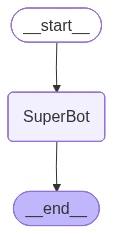

In [11]:
## Display
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

***
### Test the graph

In [12]:
res = graph.invoke({"messages":"Hey My name is Andrew!"})

In [13]:
from rich import print as pprint

pprint(res)

{
    'messages': [
        HumanMessage(
            content='Hey My name is Andrew!',
            additional_kwargs={},
            response_metadata={},
            id='18060dbd-cec0-4d6d-bb61-06e0816547f7'
        ),
        AIMessage(
            content="Hi Andrew! It's nice to meet you! How can I help you today?",
            additional_kwargs={},
            response_metadata={
                'is_blocked': False,
                'safety_ratings': [],
                'usage_metadata': {
                    'prompt_token_count': 6,
                    'candidates_token_count': 18,
                    'total_token_count': 24,
                    'prompt_tokens_details': [{'modality': 1, 'token_count': 6}],
                    'candidates_tokens_details': [{'modality': 1, 'token_count': 18}],
                    'cached_content_token_count': 0,
                    'cache_tokens_details': []
                },
                'finish_reason': 'STOP',
                'avg_logprobs': -0.08189005984200372,
                'model_name': 'gemini-2.5-flash-lite'
            },
            id='lc_run--019dda12-a027-79f3-bdfb-5ec30541a857-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 6, 'output_tokens': 18, 'total_tokens': 24}
        )
    ]
}

In [14]:
res = graph.invoke({"messages":"What is my name?"})
pprint(res)

{
    'messages': [
        HumanMessage(
            content='What is my name?',
            additional_kwargs={},
            response_metadata={},
            id='f5b82ab4-68e4-48a1-b3c7-2c2cc19aaa53'
        ),
        AIMessage(
            content='I do not have access to your personal information, including your name. I am a large language 
model, trained by Google.',
            additional_kwargs={},
            response_metadata={
                'is_blocked': False,
                'safety_ratings': [],
                'usage_metadata': {
                    'prompt_token_count': 5,
                    'candidates_token_count': 25,
                    'total_token_count': 30,
                    'prompt_tokens_details': [{'modality': 1, 'token_count': 5}],
                    'candidates_tokens_details': [{'modality': 1, 'token_count': 25}],
                    'cached_content_token_count': 0,
                    'cache_tokens_details': []
                },
                'finish_reason': 'STOP',
                'avg_logprobs': -0.10078484535217286,
                'model_name': 'gemini-2.5-flash-lite'
            },
            id='lc_run--019dda13-2bdb-7663-95bb-61c984ae6e7c-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 5, 'output_tokens': 25, 'total_tokens': 30}
        )
    ]
}